In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial


# local imports
import sys
# sys.path.append('../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.categories import *
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.makedf.selections import *
from pyanalib.split_df_helpers import *
from pyanalib.pandas_helpers import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 
import matplotlib as mpl
plt.style.use("presentation.mplstyle")

# turn off PerformanceWarning 
# triggered by mismatched column levels
import warnings
warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning)

In [3]:
from pyanalib.split_df_helpers_new import *

## WireMod comparison — matched events (`sel_2prong`)

Compare reconstructed distributions between WireMod variations for events that survive the selection in **all** datasets (matched events).

The `sel_2prong` matched files contain diagnostic quantities (chi2, track score, …) but **not** the final-selected analysis variables. Those are compared in the [`sel_mup`](#sel_mup--final-selected-variables) section below.

**Workflow**
1. Define variable extractors and bin edges.
2. Loop through matched `.df` files **one at a time**, accumulate histogram counts (no large in-memory concat). Results are cached to `CACHE_PATH` so you can skip the file loop later.
3. Plot diagnostic comparison figures; each plot is saved as PDF + PNG under `FIG_DIR` (and per-variable ratio panels as `diagnostic_<var>`).


In [4]:
import glob as glob_module
import gc

from analysis_village.numucc_1p0pi.selection_framework import multicol_get_series
from makedf.util import avg_chi2 as _raw_avg_chi2

# ── Matched file locations ────────────────────────────────────────────────────

_YZ_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_09_223419__sel_2prong-mc-BNB_cosmics-WireModYZ/merged_perTPC"
_XTXW_DIR = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_161556__sel_2prong-mc-BNB_cosmics-WireModXTXW/merged_perTPC"
_CV_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_16_190744__sel_2prong-mc-BNB_cosmics-calovar/merged_perTPC"

yz_matched   = sorted(glob_module.glob(path.join(_YZ_DIR,   "*sel_2prong*_matched.df")))
xtxw_matched = sorted(glob_module.glob(path.join(_XTXW_DIR, "*sel_2prong*_matched.df")))
cv_matched   = sorted(glob_module.glob(path.join(_CV_DIR,   "*sel_2prong*_matched.df")))

VARIATIONS = {
    "YZ":   yz_matched,
    "XTXW": xtxw_matched,
    "CV":   cv_matched,
}

# All calo universes in matched files: evt_cv + evt_<param>_{p,m}
CALO_PARAMS = ("ccal", "alpha", "beta", "R")
ALL_UNIVERSES = ("cv",) + tuple(f"{c}_{s}" for c in CALO_PARAMS for s in ("p", "m"))
UNIVERSES_TO_PLOT = list(ALL_UNIVERSES)

# Output: cached histograms + saved figures (not on pnfs)
WIREMOD_OUT_BASE = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod"
CACHE_DIR = path.join(WIREMOD_OUT_BASE, "cache")
FIG_DIR = path.join(WIREMOD_OUT_BASE, "plots")
CACHE_PATH = path.join(CACHE_DIR, "wiremod_matched_hists.pkl")
makedirs(CACHE_DIR, exist_ok=True)
makedirs(FIG_DIR, exist_ok=True)

print("Matched file counts:")
for name, files in VARIATIONS.items():
    print(f"  {name}: {len(files)} files")
print(f"Cache: {CACHE_PATH}")
print(f"Figures: {FIG_DIR}")

Matched file counts:
  YZ: 88 files
  XTXW: 95 files
  CV: 84 files
Cache: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists.pkl
Figures: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots


In [5]:
# ── Variable definitions ──────────────────────────────────────────────────────
#
# Each entry: name -> dict with keys:
#   label    : axis label
#   bins     : 1-D bin-edge array
#   extract  : callable(evt_df) -> 1-D np.ndarray of values to histogram
#              evt_df has trk1 / trk2 as top-level column groups
#
# Per-track variables are extracted from trk1 + trk2 concatenated.
# Per-event variables are extracted directly from the evt df.

def _safe_avg_chi2(trk_df, chi2_name):
    """Average per-plane chi2 over planes I0/I1/I2; return empty array on error."""
    try:
        return _raw_avg_chi2(trk_df, chi2_name).to_numpy(dtype=float)
    except Exception:
        return np.array([], dtype=float)


def _per_trk(evt_df, fn):
    """Apply fn to trk1 and trk2 sub-dfs, concatenate, return float array."""
    out = []
    top_cols = evt_df.columns.get_level_values(0).unique()
    for trk in ("trk1", "trk2"):
        if trk not in top_cols:
            continue
        try:
            vals = np.asarray(fn(evt_df[trk]), dtype=float)
            if vals.ndim == 1:
                out.append(vals)
        except Exception:
            pass
    return np.concatenate(out) if out else np.array([], dtype=float)


def _per_trk_col(evt_df, col_tuple):
    """Extract a MultiIndex column from each track and concatenate."""
    return _per_trk(
        evt_df,
        lambda t: multicol_get_series(t, col_tuple).to_numpy(dtype=float),
    )


def _per_evt_col(evt_df, col_tuple):
    try:
        return multicol_get_series(evt_df, col_tuple).to_numpy(dtype=float)
    except Exception:
        return np.array([], dtype=float)


VAR_DEFS = {
    # ── chi2 (priority variables) ─────────────────────────────────────────
    "chi2_mu": {
        "label": r"$\langle\chi^2_\mu\rangle$ (per track)",
        "bins":  np.linspace(0, 55, 56),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_muon_new")),
    },
    "chi2_p": {
        "label": r"$\langle\chi^2_p\rangle$ (per track)",
        "bins":  np.linspace(0, 300, 61),
        "extract": lambda df: _per_trk(df, lambda t: _safe_avg_chi2(t, "chi2_proton_new")),
    },
    # ── track shape ───────────────────────────────────────────────────────
    "track_score": {
        "label": "PFP Track Score (per track)",
        "bins":  np.linspace(0.2, 1.0, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "trackScore", "", "", "", "")),
    },
    "trk_len": {
        "label": "Track Length (cm, per track)",
        "bins":  np.linspace(0, 200, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "trk", "len", "", "", "")),
    },
    "vtx_dist": {
        "label": "Vertex Distance (cm, per track)",
        "bins":  np.linspace(0, 6, 41),
        "extract": lambda df: _per_trk_col(df, ("pfp", "pfochar", "vtxdist", "", "", "")),
    },
    # ── kinematics ────────────────────────────────────────────────────────
    "muon_p": {
        "label": r"$P_\mu$ (GeV/c)",
        "bins":  np.linspace(0.1, 1.2, 45),
        "extract": lambda df: _per_evt_col(df, ("mu", "pfp", "trk", "P", "p_muon", "", "")),
    },
    "proton_p": {
        "label": r"$P_p$ (GeV/c)",
        "bins":  np.linspace(0.2, 1.2, 41),
        "extract": lambda df: _per_evt_col(df, ("p", "pfp", "trk", "P", "p_proton", "", "")),
    },
}

# ── Final-selected evt variables (same set as syst_detvar_chunk PER_EVT_PLOTS) ─
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
    with_final_selected_evt_variables,
)


def var_def_from_config(vc):
    col = vc.var_evt_reco_col
    return {
        "label": vc.var_labels[0] if vc.var_labels else vc.var_plot_name,
        "bins": np.asarray(vc.bins),
        "extract": lambda df, col=col: _per_evt_col(df, col),
    }


_final_evt_configs = with_final_selected_evt_variables(
    list(CORE_SELECTED_EVT_VARIABLE_CONFIGS)
)
_ne_cfg = VariableConfig.neutrino_energy()
if _ne_cfg.var_save_name not in {c.var_save_name for c in _final_evt_configs}:
    _final_evt_configs.append(_ne_cfg)

FINAL_VAR_DEFS = {}
for vc in _final_evt_configs:
    if vc.var_save_name == "integrated":
        # Single-bin integrated rate: all selected events in one histogram bin.
        FINAL_VAR_DEFS["integrated"] = {
            "label": vc.var_labels[0] if vc.var_labels else vc.var_plot_name,
            "bins": np.asarray(vc.bins),
            "extract": lambda df: np.full(len(df), 500.0, dtype=float),
        }
        continue
    FINAL_VAR_DEFS[vc.var_save_name] = var_def_from_config(vc)

MUP_VAR_DEFS = {**VAR_DEFS, **FINAL_VAR_DEFS}

print(f"Diagnostic variables ({len(VAR_DEFS)}):", list(VAR_DEFS.keys()))
print(f"Final-selected variables for sel_mup ({len(FINAL_VAR_DEFS)}):", list(FINAL_VAR_DEFS.keys()))

Diagnostic variables (7): ['chi2_mu', 'chi2_p', 'track_score', 'trk_len', 'vtx_dist', 'muon_p', 'proton_p']
Final-selected variables for sel_mup (24): ['integrated', 'muon-p', 'muon-dir_z', 'proton-p', 'proton-dir_z', 'tki-del_Tp', 'tki-del_Tp_x', 'tki-del_Tp_y', 'tki-del_p', 'tki-del_alpha', 'tki-del_phi', 'muon-dir_phi', 'proton-dir_phi', 'muon-dir_x', 'muon-dir_y', 'proton-dir_x', 'proton-dir_y', 'vertex_x', 'vertex_y', 'vertex_z', 'muon-end_x', 'muon-end_y', 'muon-end_z', 'E_nu']


In [6]:
# ── Chunked histogram accumulation ───────────────────────────────────────────
# Mirrors the syst_detvar_chunk.py strategy: read one file-split at a time,
# fill histogram counts, then drop the dataframe immediately.

def _fill_hists_from_split(df, var_defs, hists):
    """Extract all variables from a single split df and accumulate into hists."""
    if df is None or len(df) == 0:
        return 0
    n = len(df)
    for var_name, cfg in var_defs.items():
        try:
            vals = cfg["extract"](df)
        except Exception:
            continue
        vals = np.asarray(vals, dtype=float)
        vals = vals[np.isfinite(vals)]
        if len(vals) == 0:
            continue
        eps = (cfg["bins"][-1] - cfg["bins"][0]) * 1e-9
        vals = np.clip(vals, cfg["bins"][0], cfg["bins"][-1] - eps)
        counts, _ = np.histogram(vals, bins=cfg["bins"])
        hists[var_name] += counts
    return n


def accumulate_variation(matched_files, universes, var_defs):
    """
    Loop through all matched files for one variation.
    Returns:
        hists   : dict  univ -> var_name -> np.ndarray (bin counts)
        n_evts  : dict  univ -> int (total events seen)
    """
    hists  = {u: {v: np.zeros(len(cfg["bins"]) - 1, dtype=float)
                  for v, cfg in var_defs.items()}
              for u in universes}
    n_evts = {u: 0 for u in universes}

    for fpath in tqdm(matched_files):
        try:
            n_split = get_n_split(fpath)
        except Exception as e:
            print(f"  skip {path.basename(fpath)}: {e}", flush=True)
            continue

        for i in range(n_split):
            for univ in universes:
                key = f"evt_{univ}_{i}"
                try:
                    df = pd.read_hdf(fpath, key=key)
                except Exception:
                    continue

                n = _fill_hists_from_split(df, var_defs, hists[univ])
                n_evts[univ] += n
                del df
            gc.collect()

    return hists, n_evts


# ── Save / load cached histograms (for replot without re-scanning files) ─────

import pickle


def save_wiremod_hists(cache_path, all_hists, all_nevts, var_defs, variations, universes):
    var_meta = {
        name: {"label": cfg["label"], "bins": np.asarray(cfg["bins"])}
        for name, cfg in var_defs.items()
    }
    payload = {
        "version": 1,
        "variations": list(variations.keys()),
        "universes": list(universes),
        "diag_var_names": [n for n in var_defs if n in VAR_DEFS],
        "final_var_names": [n for n in var_defs if n in FINAL_VAR_DEFS],
        "var_defs": var_meta,
        "hists": {
            vl: {u: {vn: arr.copy() for vn, arr in uh.items()} for u, uh in h.items()}
            for vl, h in all_hists.items()
        },
        "n_evts": all_nevts,
    }
    with open(cache_path, "wb") as fh:
        pickle.dump(payload, fh, protocol=pickle.HIGHEST_PROTOCOL)
    print(f"Saved histogram cache → {cache_path}", flush=True)
    return payload


def load_wiremod_hists(cache_path):
    with open(cache_path, "rb") as fh:
        payload = pickle.load(fh)
    print(
        f"Loaded cache: {len(payload['variations'])} variations, "
        f"{len(payload['universes'])} universes, "
        f"{len(payload['var_defs'])} variables",
        flush=True,
    )
    return payload


# Set False to skip accumulation and load CACHE_PATH in the next cell instead
RUN_ACCUMULATION = True

if RUN_ACCUMULATION:
    all_hists = {}
    all_nevts = {}
    for var_label, files in VARIATIONS.items():
        print(f"\n[{var_label}] accumulating over {len(files)} files …")
        h, n = accumulate_variation(files, UNIVERSES_TO_PLOT, VAR_DEFS)
        all_hists[var_label] = h
        all_nevts[var_label] = n
        print(f"  {var_label} / cv: {n['cv']:,} events")
    save_wiremod_hists(
        CACHE_PATH, all_hists, all_nevts, VAR_DEFS, VARIATIONS, UNIVERSES_TO_PLOT
    )
else:
    print("Skipping accumulation (set RUN_ACCUMULATION=True to rebuild cache)")


[YZ] accumulating over 88 files …


100%|██████████| 88/88 [06:58<00:00,  4.76s/it]


  YZ / cv: 1,059,468 events

[XTXW] accumulating over 95 files …


100%|██████████| 95/95 [07:06<00:00,  4.48s/it]


  XTXW / cv: 1,084,789 events

[CV] accumulating over 84 files …


100%|██████████| 84/84 [06:34<00:00,  4.70s/it]

  CV / cv: 1,063,844 events
Saved histogram cache → /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists.pkl


In [7]:
# ── Plot helpers + histogram metadata for replotting ─────────────────────────

VAR_COLORS = {"YZ": "C0", "XTXW": "C1", "CV": "C2"}

# Figure aspect matches overlay / universe plots in utils.py
UNIV_FIGSIZE = (8.5, 7)
UNIV_RATIO_FIGSIZE = (8.5, 8.5)
UNIV_RATIO_HEIGHT_RATIOS = [4, 1]

if RUN_ACCUMULATION and all_hists:
    PLOT_VAR_DEFS = {
        n: {"label": c["label"], "bins": np.asarray(c["bins"])}
        for n, c in VAR_DEFS.items()
    }
    DIAG_VAR_NAMES = list(PLOT_VAR_DEFS.keys())
else:
    _payload = load_wiremod_hists(CACHE_PATH)
    all_hists = _payload["hists"]
    all_nevts = _payload["n_evts"]
    PLOT_VAR_DEFS = _payload["var_defs"]
    DIAG_VAR_NAMES = _payload.get("diag_var_names", list(PLOT_VAR_DEFS.keys()))


def save_fig(fig, name, fig_dir=FIG_DIR, dpi=150):
    makedirs(fig_dir, exist_ok=True)
    for ext in ("pdf", "png"):
        out = path.join(fig_dir, f"{name}.{ext}")
        fig.savefig(out, bbox_inches="tight", dpi=dpi)
    print(f"  saved {name}.pdf / .png")


def display_saved_figure(name, fig_dir=FIG_DIR, ext="png"):
    """Show a figure previously written by save_fig (no matplotlib rebuild)."""
    from IPython.display import Image, display

    fpath = path.join(fig_dir, f"{name}.{ext}")
    if not path.isfile(fpath):
        print(f"not found: {fpath}")
        return
    print(fpath)
    display(Image(filename=fpath))


def list_saved_figures(fig_dir=FIG_DIR, ext="png"):
    """Print paths of saved figures in fig_dir."""
    pattern = path.join(fig_dir, f"*{ext}")
    paths = sorted(glob_module.glob(pattern))
    print(f"{len(paths)} {ext} files in {fig_dir}")
    for p in paths:
        print(f"  {path.basename(p)}")
    return paths


def _shifted_univ_keys(hists, shifted_univs=None):
    if shifted_univs is not None:
        return [u for u in shifted_univs if u in hists]
    return [u for u in hists if u != "cv"]


def _draw_calo_envelope(ax, hists, var_name, bins, color, shifted_univs, normalize=True):
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys:
        return
    rows = []
    for u in keys:
        cnt = hists[u][var_name].copy()
        total = cnt.sum()
        if total == 0:
            continue
        if normalize:
            cnt = cnt / total
        rows.append(cnt)
    if not rows:
        return
    shifted = np.stack(rows, axis=0)
    lo, hi = shifted.min(axis=0), shifted.max(axis=0)
    ax.fill_between(
        bins,
        np.append(lo, lo[-1]),
        np.append(hi, hi[-1]),
        step="post",
        color=color,
        alpha=0.2,
    )


def _draw_calo_ratio_envelope(
    ax, hists, var_name, bins, color, reference_counts, shifted_univs, normalize=True
):
    """Min/max ratio to reference over calo-shift universes."""
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys or reference_counts is None:
        return
    rows = []
    for u in keys:
        cnt = hists[u][var_name].copy()
        total = cnt.sum()
        if total == 0:
            continue
        if normalize:
            cnt = cnt / total
        with np.errstate(divide="ignore", invalid="ignore"):
            rat = np.where(reference_counts > 0, cnt / reference_counts, np.nan)
        rows.append(rat)
    if not rows:
        return
    shifted = np.stack(rows, axis=0)
    lo, hi = np.nanmin(shifted, axis=0), np.nanmax(shifted, axis=0)
    ax.fill_between(
        bins,
        np.append(lo, lo[-1]),
        np.append(hi, hi[-1]),
        step="post",
        color=color,
        alpha=0.2,
    )


def plot_var_comparison(
    var_name,
    var_cfg,
    all_hists,
    univ="cv",
    ax=None,
    axes=None,
    normalize=True,
    ratio=False,
    reference_key=None,
    ratio_ylim=None,
    ratio_ylabel=None,
    clip_xlim=False,
    legend_frameon=True,
    show_title=True,
    calo_envelope=False,
    shifted_univs=None,
    legend_fontsize=9,
):
    bins = np.asarray(var_cfg["bins"])
    if axes is not None:
        ax_top, ax_bot = axes
        make_fig = False
        fig = None
        ratio = True
    elif ax is not None:
        ax_top = ax
        ax_bot = None
        make_fig = False
        fig = None
    else:
        make_fig = True
        fig, axes_out = plt.subplots(
            2 if ratio else 1, 1,
            # figsize=UNIV_RATIO_FIGSIZE if ratio else UNIV_FIGSIZE,
            figsize=(7, 6),
            gridspec_kw={"height_ratios": UNIV_RATIO_HEIGHT_RATIOS} if ratio else None,
            sharex=True,
        )
        if ratio:
            fig.subplots_adjust(hspace=0.1)
        ax_top = axes_out[0] if ratio else axes_out
        ax_bot = axes_out[1] if ratio else None

    reference_counts = None
    reference_label = reference_key

    if reference_key is not None and reference_key in all_hists:
        ref_raw = all_hists[reference_key][univ][var_name].copy()
        ref_total = ref_raw.sum()
        if ref_total > 0:
            reference_counts = ref_raw / ref_total if normalize else ref_raw

    for var_label, hists in all_hists.items():
        counts = hists[univ][var_name].copy()
        total = counts.sum()
        if total == 0:
            continue
        if normalize:
            counts = counts / total
        color = VAR_COLORS.get(var_label, None)
        ax_top.step(
            bins,
            np.append(counts, counts[-1]),
            where="post",
            label=var_label,
            color=color,
            linewidth=1.5,
        )
        if calo_envelope:
            _draw_calo_envelope(
                ax_top, hists, var_name, bins, color, shifted_univs, normalize=normalize
            )
        if reference_counts is None:
            reference_counts = counts.copy()
            reference_label = var_label

    ax_top.set_ylabel("Events (normalised)" if normalize else "Events")
    ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)
    if show_title:
        ax_top.set_title(var_cfg["label"], fontsize=10)
    if calo_envelope:
        import matplotlib.patches as mpatches

        envelope_patch = mpatches.Patch(
            color="gray", alpha=0.2, label="Calorimetry variation envelope"
        )
        handles, labels = ax_top.get_legend_handles_labels()
        if not any(lbl == "Calorimetry variation envelope" for lbl in labels):
            handles.append(envelope_patch)
            labels.append("Calorimetry variation envelope")
            ax_top.legend(handles, labels, fontsize=legend_fontsize, frameon=legend_frameon)

    if clip_xlim:
        ax_top.set_xlim(bins[0], bins[-1])

    if ratio and ax_bot is not None and reference_counts is not None:
        ax_bot.axhline(1.0, color="k", linewidth=0.8, linestyle="--")
        for var_label, hists in all_hists.items():
            if reference_key is not None:
                if var_label == reference_key:
                    continue
            elif var_label == reference_label:
                continue
            counts = hists[univ][var_name].copy()
            total = counts.sum()
            if total == 0:
                continue
            if normalize:
                counts = counts / total
            with np.errstate(divide="ignore", invalid="ignore"):
                rat = np.where(reference_counts > 0, counts / reference_counts, np.nan)
            color = VAR_COLORS.get(var_label, None)
            ax_bot.step(
                bins,
                np.append(rat, rat[-1]),
                where="post",
                color=color,
                linewidth=1.5,
            )
            if calo_envelope:
                _draw_calo_ratio_envelope(
                    ax_bot,
                    hists,
                    var_name,
                    bins,
                    color,
                    reference_counts,
                    shifted_univs,
                    normalize=normalize,
                )
        ax_bot.set_ylabel(
            ratio_ylabel if ratio_ylabel is not None else f"/ {reference_label}",
            fontsize=8,
        )
        ax_bot.set_ylim(ratio_ylim if ratio_ylim is not None else (0.8, 1.2))
        ax_bot.set_xlabel(var_cfg["label"])
        if clip_xlim:
            ax_bot.set_xlim(bins[0], bins[-1])

    if make_fig:
        plt.tight_layout()
        return fig
    return None

/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)


  saved diagnostic_all.pdf / .png


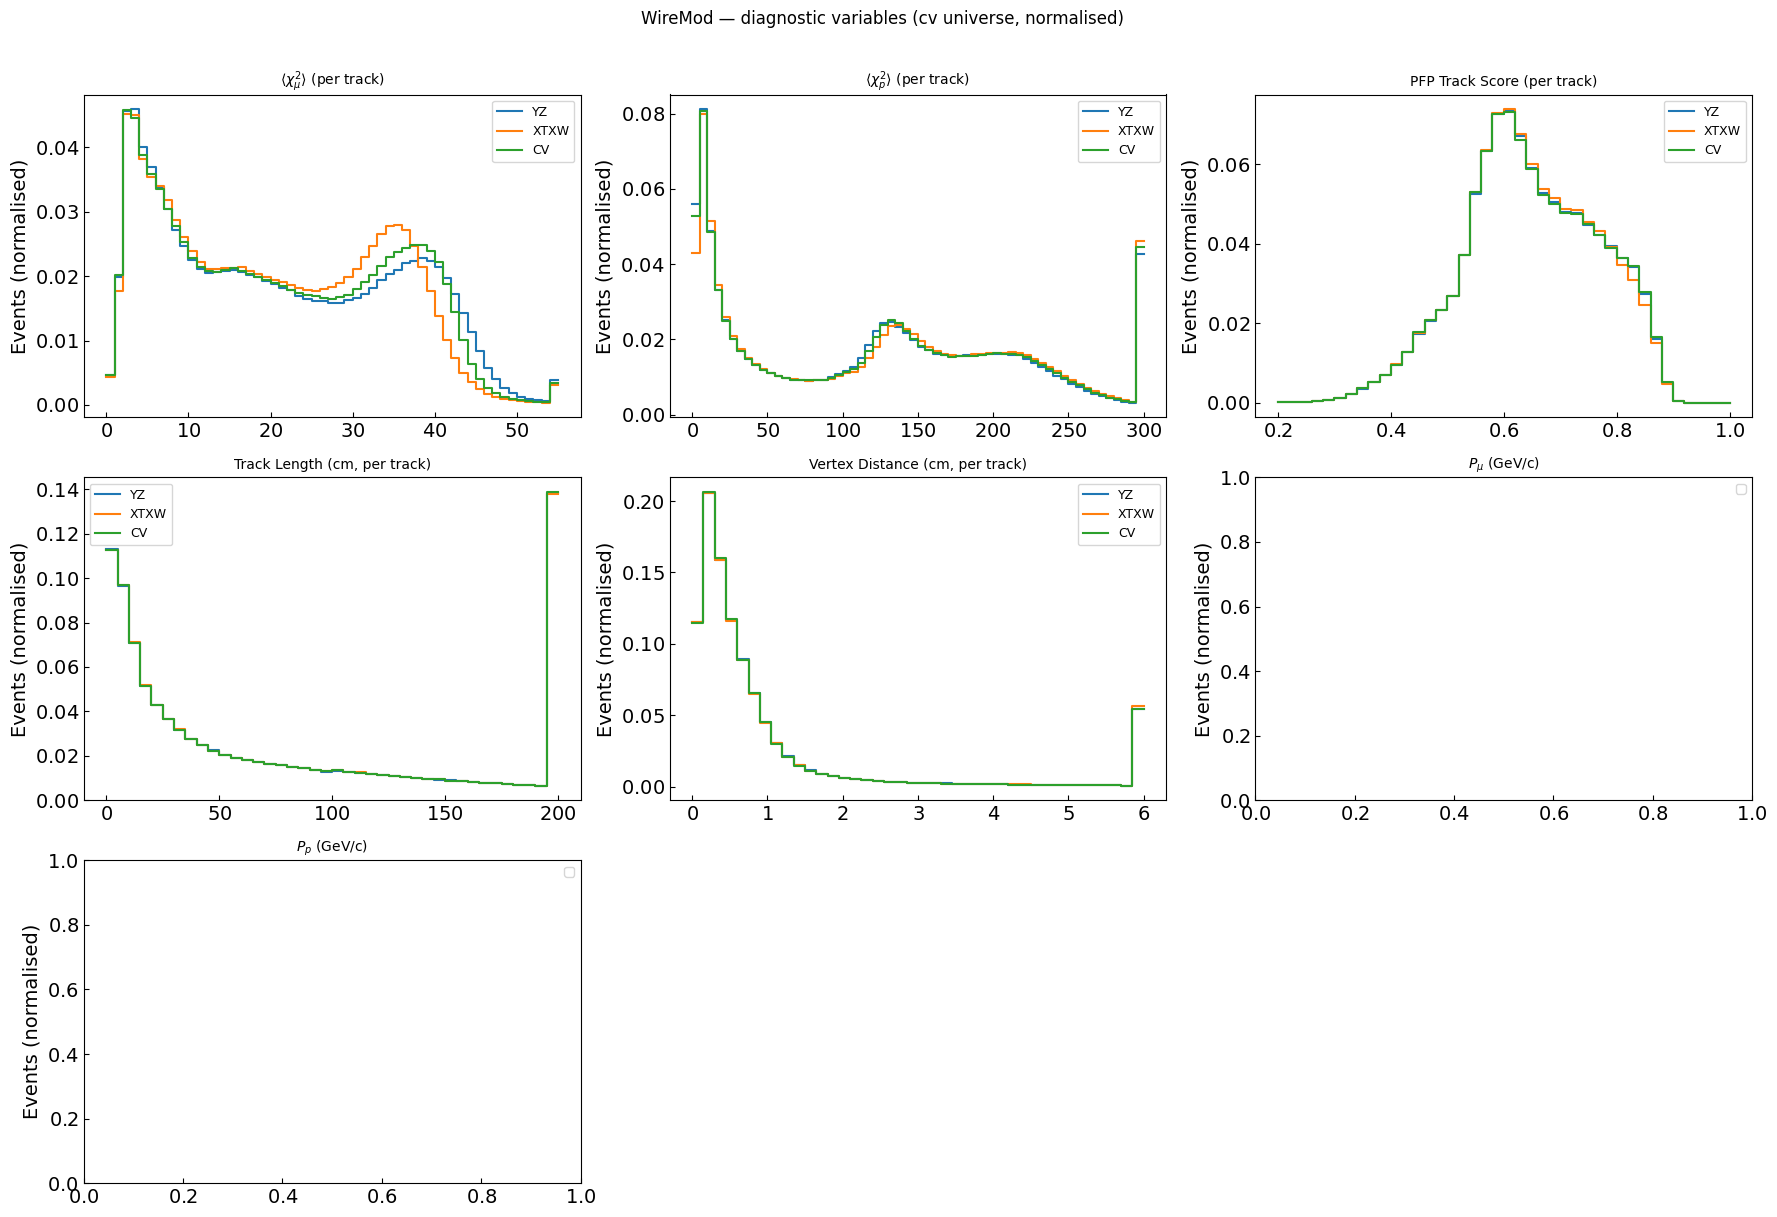

  saved diagnostic_chi2_mu.pdf / .png
  saved diagnostic_chi2_p.pdf / .png
  saved diagnostic_track_score.pdf / .png
  saved diagnostic_trk_len.pdf / .png
  saved diagnostic_vtx_dist.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)


  saved diagnostic_muon_p.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)


  saved diagnostic_proton_p.pdf / .png


In [8]:
# ── Diagnostic variables (chi2, track score, …) ───────────────────────────────

ncols = 3
nrows = (len(DIAG_VAR_NAMES) + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows))
axes = np.array(axes).flatten()

for idx, var_name in enumerate(DIAG_VAR_NAMES):
    plot_var_comparison(var_name, PLOT_VAR_DEFS[var_name], all_hists,
                        univ="cv", ax=axes[idx], ratio=False)

for idx in range(len(DIAG_VAR_NAMES), len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("WireMod — diagnostic variables (cv universe, normalised)", y=1.01)
plt.tight_layout()
save_fig(fig, "diagnostic_all")
plt.show()

for var_name in DIAG_VAR_NAMES:
    fig = plot_var_comparison(
        var_name, PLOT_VAR_DEFS[var_name], all_hists, univ="cv", ratio=True
    )
    save_fig(fig, f"diagnostic_{var_name}")
    plt.close(fig)

  saved chi2_comparison.pdf / .png


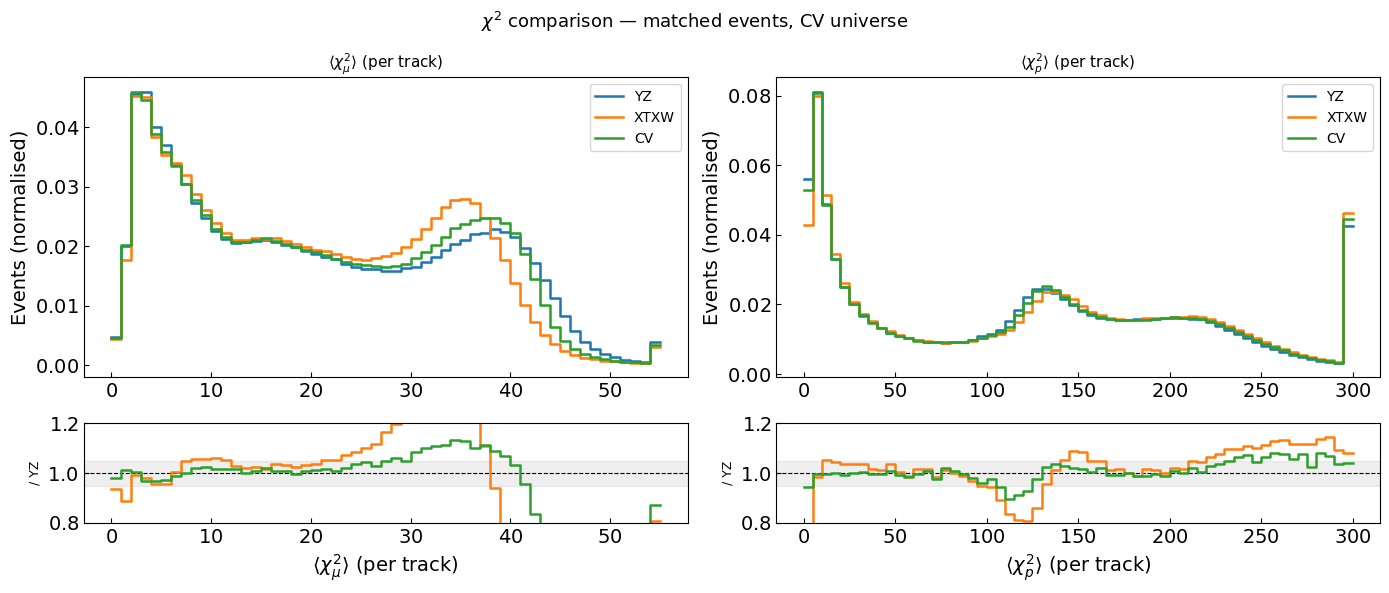

In [9]:
# ── Focused chi2 comparison with ratio panels ─────────────────────────────────

chi2_vars = {k: PLOT_VAR_DEFS[k] for k in ["chi2_mu", "chi2_p"] if k in PLOT_VAR_DEFS}

fig, axes = plt.subplots(
    2, len(chi2_vars),
    figsize=(7 * len(chi2_vars), 6),
    gridspec_kw={"height_ratios": [3, 1]},
)
if len(chi2_vars) == 1:
    axes = axes[:, np.newaxis]

for col, (var_name, var_cfg) in enumerate(chi2_vars.items()):
    ax_top = axes[0, col]
    ax_bot = axes[1, col]
    bins    = var_cfg["bins"]
    centers = (bins[:-1] + bins[1:]) / 2

    reference_counts = None
    reference_label  = None

    for var_label, hists in all_hists.items():
        counts = hists["cv"][var_name].copy()
        total  = counts.sum()
        if total == 0:
            continue
        norm = counts / total
        err  = np.sqrt(counts) / total       # Poisson uncertainty on normalised bin
        color = VAR_COLORS.get(var_label, None)

        ax_top.step(bins, np.append(norm, norm[-1]),
                    where="post", label=var_label, color=color, linewidth=1.8)
        ax_top.fill_between(bins, np.append(norm - err, (norm - err)[-1]),
                             np.append(norm + err, (norm + err)[-1]),
                             step="post", alpha=0.15, color=color)

        if reference_counts is None:
            reference_counts = norm
            reference_label  = var_label

    ax_top.set_ylabel("Events (normalised)")
    ax_top.legend(fontsize=10)
    ax_top.set_title(var_cfg["label"], fontsize=11)

    # ratio
    ax_bot.axhline(1.0, color="k", linewidth=0.8, linestyle="--")
    ax_bot.axhspan(0.95, 1.05, color="grey", alpha=0.12)
    for var_label, hists in all_hists.items():
        if var_label == reference_label:
            continue
        counts = hists["cv"][var_name].copy()
        total  = counts.sum()
        if total == 0:
            continue
        norm = counts / total
        with np.errstate(divide="ignore", invalid="ignore"):
            rat = np.where(reference_counts > 0, norm / reference_counts, np.nan)
        color = VAR_COLORS.get(var_label, None)
        ax_bot.step(bins, np.append(rat, rat[-1]),
                    where="post", color=color, linewidth=1.8)

    ax_bot.set_ylim(0.8, 1.2)
    ax_bot.set_ylabel(f"/ {reference_label}", fontsize=9)
    ax_bot.set_xlabel(var_cfg["label"])

fig.suptitle(r"$\chi^2$ comparison — matched events, CV universe", fontsize=13)
plt.tight_layout()
save_fig(fig, "chi2_comparison")
plt.show()

  saved chi2_calo_envelope.pdf / .png


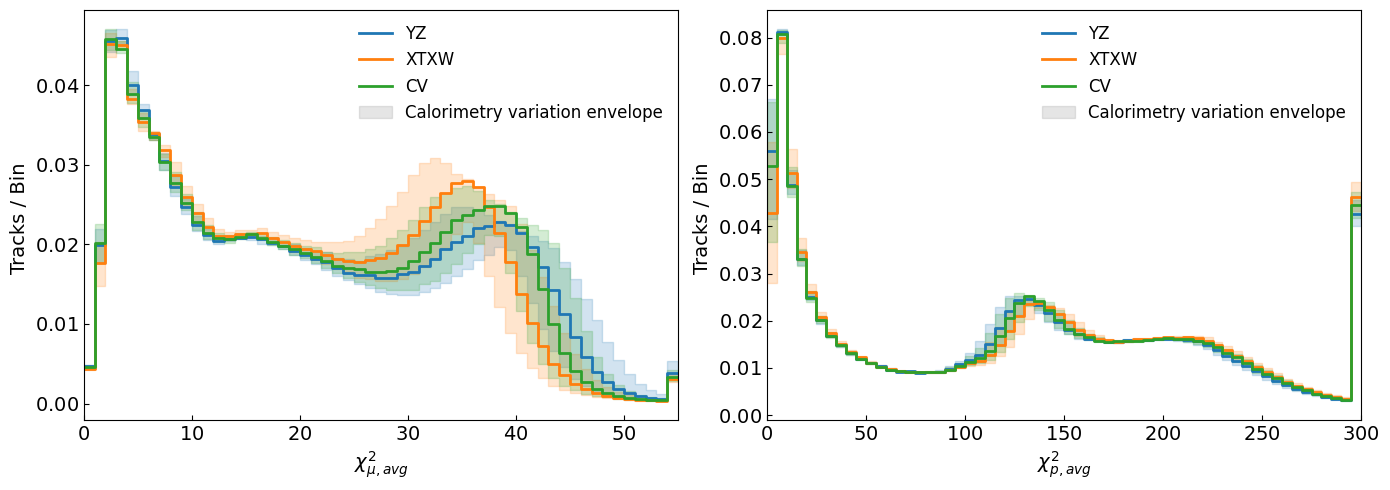

In [10]:
# ── Chi2 per-variation envelope: cv vs calo shifts within each variation ──────

import matplotlib.patches as mpatches

example_hists = next(iter(all_hists.values()))
available_univs = [u for u in ALL_UNIVERSES if u in example_hists]
shifted_univs = [u for u in available_univs if u != "cv"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
chi2_keys = [("chi2_mu", r"$\chi^2_{\mu, avg}$"),
             ("chi2_p",  r"$\chi^2_{p, avg}$")]

for ax, (var_name, var_title) in zip(axes, chi2_keys):
    bins = PLOT_VAR_DEFS[var_name]["bins"]

    for var_label, hists in all_hists.items():
        color = VAR_COLORS.get(var_label, None)
        cv_cnt = hists["cv"][var_name]
        total = cv_cnt.sum()
        if total == 0:
            continue
        cv_norm = cv_cnt / total
        ax.step(bins, np.append(cv_norm, cv_norm[-1]),
                where="post", color=color, linewidth=2,
                label=f"{var_label}")

        if shifted_univs:
            shifted = np.stack(
                [hists[u][var_name] / (hists[u][var_name].sum() or 1)
                 for u in shifted_univs],
                axis=0,
            )
            lo = shifted.min(axis=0)
            hi = shifted.max(axis=0)
            fill = ax.fill_between(
                bins, np.append(lo, lo[-1]), np.append(hi, hi[-1]),
                step="post", color=color, alpha=0.2
            )
            # Optionally you can keep these fill_between objects for the legend, below.
            # label=f"{var_label} calo env.")

    # Add a legend entry for the envelope
    envelope_patch = mpatches.Patch(color='gray', alpha=0.2, label="Calorimetry variation envelope")
    # Get current handles and labels for the legend
    handles, labels = ax.get_legend_handles_labels()
    # Add the envelope patch if it isn't already in the handles
    if not any(lbl == "Calorimetry variation envelope" for lbl in labels):
        handles.append(envelope_patch)
        labels.append("Calorimetry variation envelope")

    ax.set_xlabel(var_title)
    ax.set_xlim(bins[0], bins[-1])
    ax.set_ylabel("Tracks / Bin ")
    ax.legend(handles, labels, fontsize=12, frameon=False)
    # ax.set_title(var_title

# fig.suptitle(r"$\chi^2$ distributions + calo-shift envelope", fontsize=12)
plt.tight_layout()
save_fig(fig, "chi2_calo_envelope")
plt.show()

---

## WireMod comparison — matched events (`sel_mup`) {#sel-mup--final-selected-variables}

Same matched-event workflow as above, using `sel_mup` files that include the **final-selected** analysis variables (muon/proton kinematics, TKI, vertex, $E_\nu$, …).

Set `RUN_ACCUMULATION_MUP = False` to replot from `CACHE_PATH_MUP` without re-scanning files.


In [11]:
# ── sel_mup matched file locations (see run_match_detvars.sh) ───────────────

_MUP_YZ_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_17_170153__sel_mup-mc-WireModYZ/merged_perTPC"
_MUP_XTXW_DIR = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_17_165611__sel_mup-mc-WireModXTXW/merged_perTPC"
_MUP_CV_DIR   = "/pnfs/sbnd/scratch/users/munjung/cafpyana_out/dfs/2026_05_17_165121__sel_mup-mc-BNB_cosmics-calovar/merged_perTPC"

yz_mup_matched   = sorted(glob_module.glob(path.join(_MUP_YZ_DIR,   "*sel_mup*_matched.df")))
xtxw_mup_matched = sorted(glob_module.glob(path.join(_MUP_XTXW_DIR, "*sel_mup*_matched.df")))
cv_mup_matched   = sorted(glob_module.glob(path.join(_MUP_CV_DIR,   "*sel_mup*_matched.df")))

VARIATIONS_MUP = {
    "YZ":   yz_mup_matched,
    "XTXW": xtxw_mup_matched,
    "CV":   cv_mup_matched,
}

CACHE_PATH_MUP = path.join(CACHE_DIR, "wiremod_matched_hists_sel_mup.pkl")
FIG_DIR_MUP = path.join(FIG_DIR, "sel_mup")
makedirs(FIG_DIR_MUP, exist_ok=True)

print("sel_mup matched file counts:")
for name, files in VARIATIONS_MUP.items():
    print(f"  {name}: {len(files)} files")
print(f"Cache: {CACHE_PATH_MUP}")
print(f"Figures: {FIG_DIR_MUP}")


sel_mup matched file counts:
  YZ: 47 files
  XTXW: 47 files
  CV: 46 files
Cache: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists_sel_mup.pkl
Figures: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots/sel_mup


In [12]:
RUN_ACCUMULATION_MUP = True

if RUN_ACCUMULATION_MUP:
    all_hists_mup = {}
    all_nevts_mup = {}
    for var_label, files in VARIATIONS_MUP.items():
        print(f"\n[{var_label}] sel_mup — accumulating over {len(files)} files …")
        h, n = accumulate_variation(files, UNIVERSES_TO_PLOT, MUP_VAR_DEFS)
        all_hists_mup[var_label] = h
        all_nevts_mup[var_label] = n
        print(f"  {var_label} / cv: {n['cv']:,} events")
    save_wiremod_hists(
        CACHE_PATH_MUP, all_hists_mup, all_nevts_mup,
        MUP_VAR_DEFS, VARIATIONS_MUP, UNIVERSES_TO_PLOT,
    )
else:
    print("Skipping sel_mup accumulation (set RUN_ACCUMULATION_MUP=True to rebuild cache)")



[YZ] sel_mup — accumulating over 47 files …


100%|██████████| 47/47 [02:01<00:00,  2.58s/it]


  YZ / cv: 118,448 events

[XTXW] sel_mup — accumulating over 47 files …


100%|██████████| 47/47 [01:58<00:00,  2.52s/it]


  XTXW / cv: 119,187 events

[CV] sel_mup — accumulating over 46 files …


100%|██████████| 46/46 [02:02<00:00,  2.66s/it]

  CV / cv: 118,483 events
Saved histogram cache → /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/cache/wiremod_matched_hists_sel_mup.pkl


In [13]:
if RUN_ACCUMULATION_MUP and all_hists_mup:
    PLOT_VAR_DEFS_MUP = {
        n: {"label": c["label"], "bins": np.asarray(c["bins"])}
        for n, c in MUP_VAR_DEFS.items()
    }
    DIAG_VAR_NAMES_MUP = [n for n in PLOT_VAR_DEFS_MUP if n in VAR_DEFS]
    FINAL_VAR_NAMES_MUP = [n for n in PLOT_VAR_DEFS_MUP if n in FINAL_VAR_DEFS]
else:
    _payload_mup = load_wiremod_hists(CACHE_PATH_MUP)
    all_hists_mup = _payload_mup["hists"]
    all_nevts_mup = _payload_mup["n_evts"]
    PLOT_VAR_DEFS_MUP = _payload_mup["var_defs"]
    DIAG_VAR_NAMES_MUP = _payload_mup.get("diag_var_names", [])
    FINAL_VAR_NAMES_MUP = _payload_mup.get("final_var_names", [])

print(f"sel_mup diagnostic vars: {len(DIAG_VAR_NAMES_MUP)}, final-selected: {len(FINAL_VAR_NAMES_MUP)}")


sel_mup diagnostic vars: 7, final-selected: 24


/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)
/tmp/ipykernel_3948223/3210009387.py:108: RuntimeWarning: All-NaN slice encountered
  lo, hi = np.nanmin(shifted, axis=0), np.nanmax(shifted, axis=0)
/tmp/ipykernel_3948223/2160719493.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


  saved final_selected_all.pdf / .png


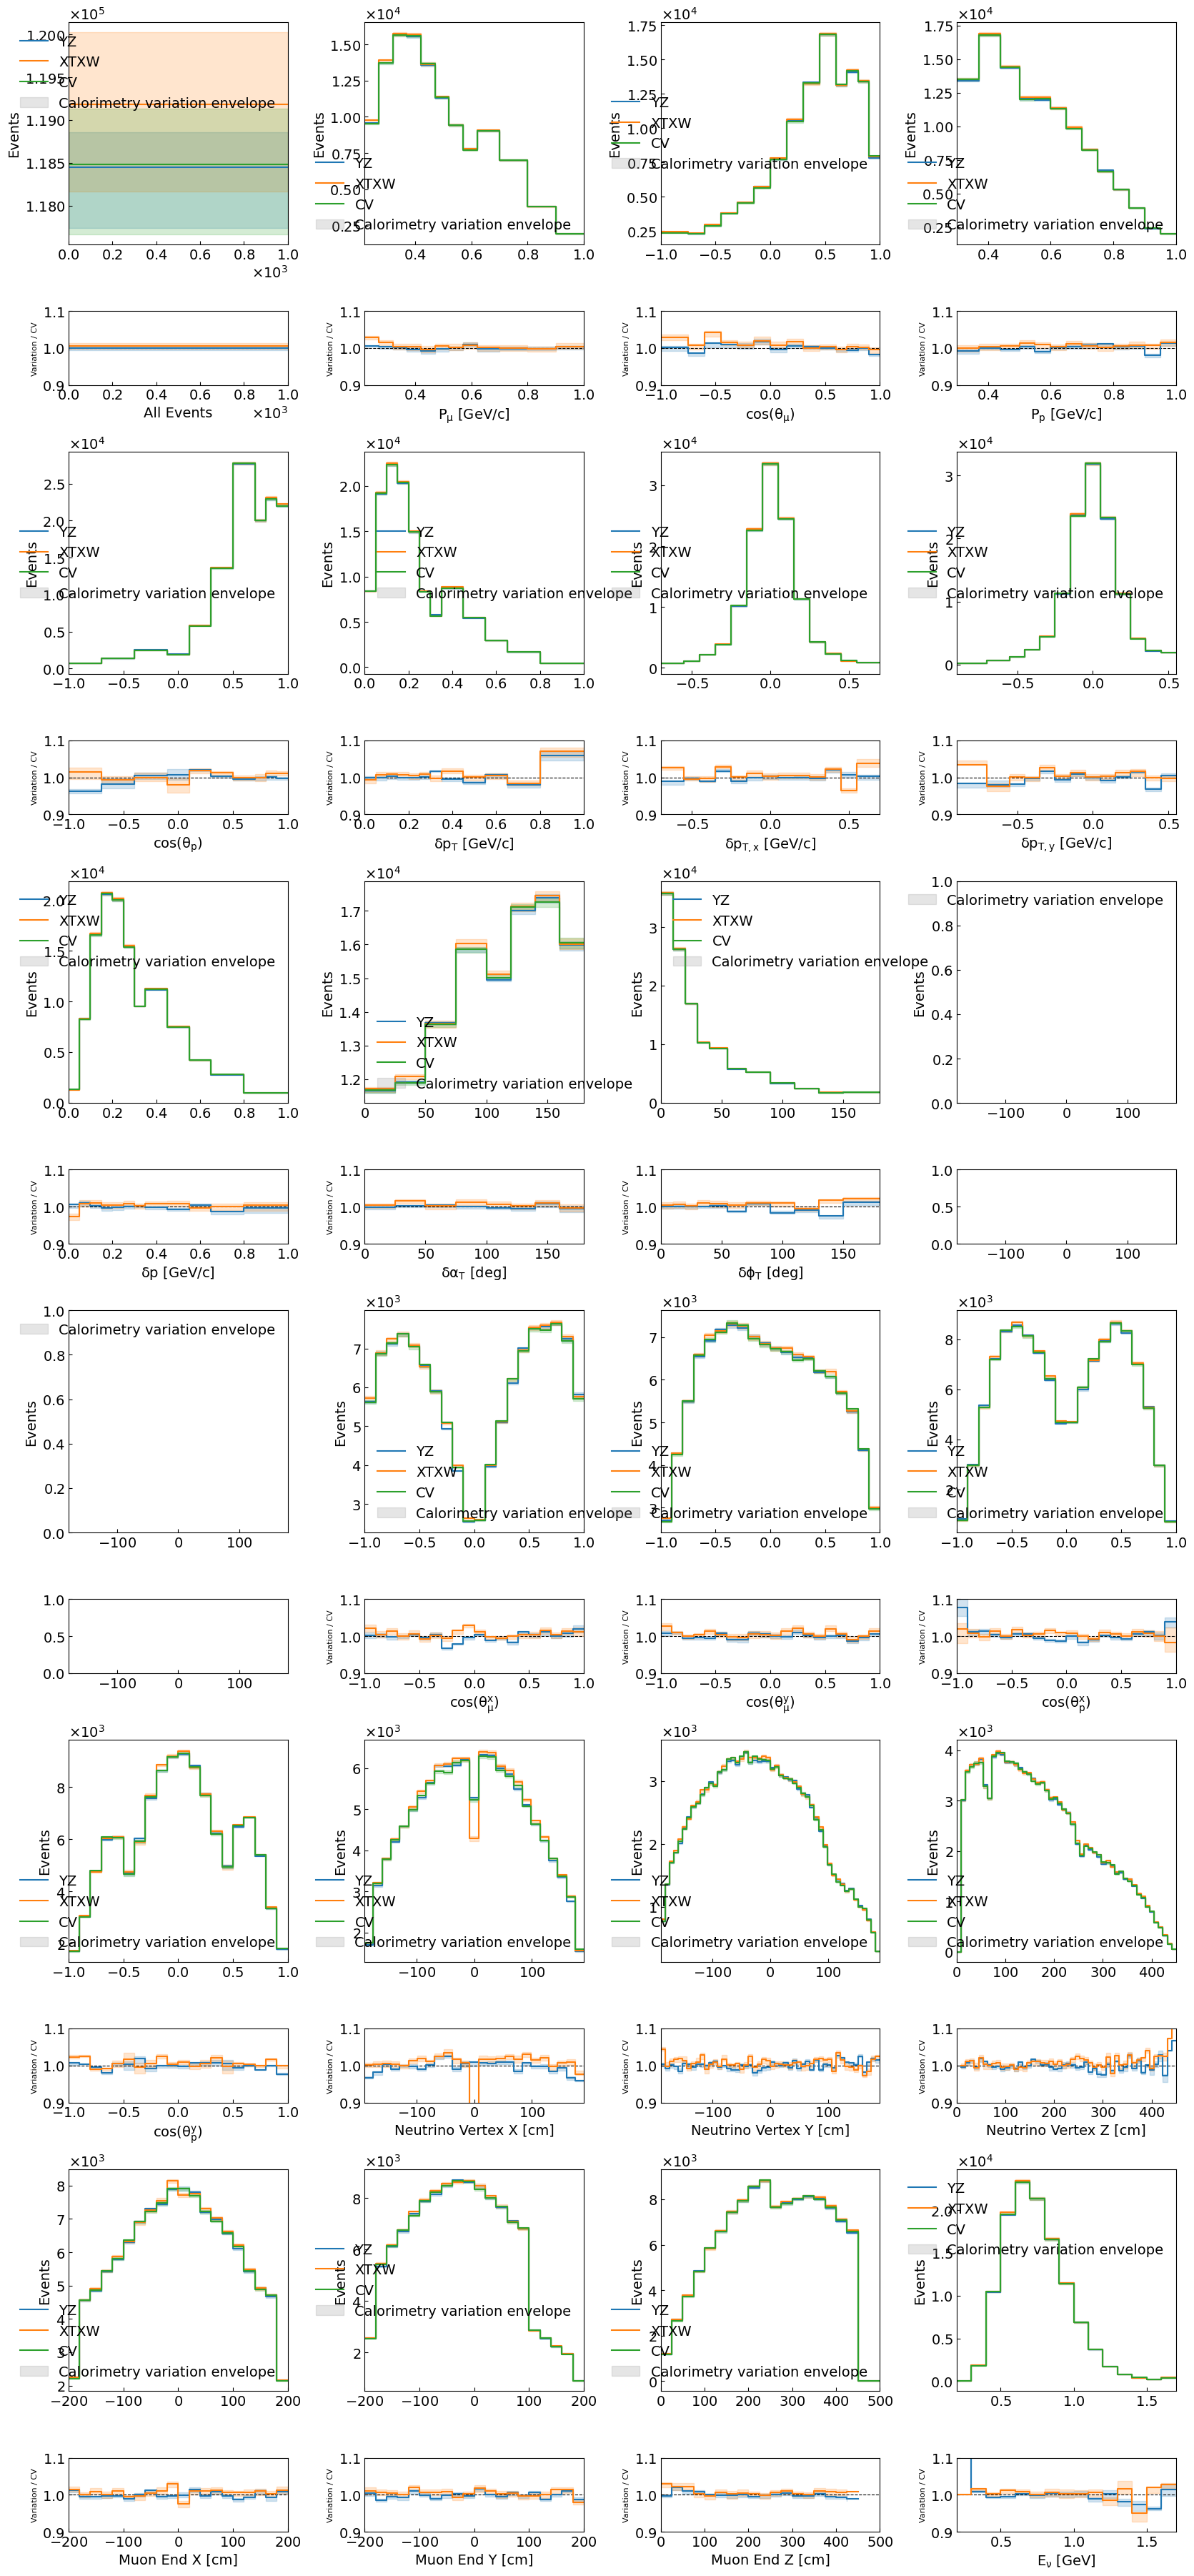

  saved final_selected_integrated.pdf / .png
  saved final_selected_muon-p.pdf / .png
  saved final_selected_muon-dir_z.pdf / .png
  saved final_selected_proton-p.pdf / .png
  saved final_selected_proton-dir_z.pdf / .png
  saved final_selected_tki-del_Tp.pdf / .png
  saved final_selected_tki-del_Tp_x.pdf / .png
  saved final_selected_tki-del_Tp_y.pdf / .png
  saved final_selected_tki-del_p.pdf / .png
  saved final_selected_tki-del_alpha.pdf / .png
  saved final_selected_tki-del_phi.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)


  saved final_selected_muon-dir_phi.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:197: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_top.legend(fontsize=legend_fontsize, frameon=legend_frameon)


  saved final_selected_proton-dir_phi.pdf / .png
  saved final_selected_muon-dir_x.pdf / .png
  saved final_selected_muon-dir_y.pdf / .png
  saved final_selected_proton-dir_x.pdf / .png
  saved final_selected_proton-dir_y.pdf / .png
  saved final_selected_vertex_x.pdf / .png
  saved final_selected_vertex_y.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:108: RuntimeWarning: All-NaN slice encountered
  lo, hi = np.nanmin(shifted, axis=0), np.nanmax(shifted, axis=0)


  saved final_selected_vertex_z.pdf / .png
  saved final_selected_muon-end_x.pdf / .png
  saved final_selected_muon-end_y.pdf / .png


/tmp/ipykernel_3948223/3210009387.py:108: RuntimeWarning: All-NaN slice encountered
  lo, hi = np.nanmin(shifted, axis=0), np.nanmax(shifted, axis=0)


  saved final_selected_muon-end_z.pdf / .png
  saved final_selected_E_nu.pdf / .png


In [14]:
# ── Final-selected variables (cv universe) ────────────────────────────────────
from matplotlib.gridspec import GridSpec

_SHIFTED_UNIVS = [u for u in ALL_UNIVERSES if u != "cv"]
_FINAL_PLOT_KW = dict(
    normalize=False,
    reference_key="CV",
    clip_xlim=True,
    legend_frameon=False,
    ratio_ylim=(0.9, 1.1),
    ratio_ylabel="Variation / CV",
    show_title=False,
    calo_envelope=True,
    shifted_univs=_SHIFTED_UNIVS,
    legend_fontsize=14,
)

ncols = 4
nvars = len(FINAL_VAR_NAMES_MUP)
nrows = (nvars + ncols - 1) // ncols
fig = plt.figure(figsize=(5 * ncols, 7.6 * nrows))
gs = GridSpec(2 * nrows, ncols, figure=fig, height_ratios=[3, 1] * nrows, hspace=0.45, wspace=0.35)

for idx, var_name in enumerate(FINAL_VAR_NAMES_MUP):
    r, c = divmod(idx, ncols)
    ax_top = fig.add_subplot(gs[2 * r, c])
    ax_bot = fig.add_subplot(gs[2 * r + 1, c], sharex=ax_top)
    plot_var_comparison(
        var_name,
        PLOT_VAR_DEFS_MUP[var_name],
        all_hists_mup,
        univ="cv",
        axes=(ax_top, ax_bot),
        ratio=True,
        **_FINAL_PLOT_KW,
    )

for idx in range(nvars, nrows * ncols):
    r, c = divmod(idx, ncols)
    fig.add_subplot(gs[2 * r, c]).set_visible(False)
    fig.add_subplot(gs[2 * r + 1, c]).set_visible(False)

fig.tight_layout()
save_fig(fig, "final_selected_all", fig_dir=FIG_DIR_MUP)
plt.show()

for var_name in FINAL_VAR_NAMES_MUP:
    fig = plot_var_comparison(
        var_name,
        PLOT_VAR_DEFS_MUP[var_name],
        all_hists_mup,
        univ="cv",
        ratio=True,
        **_FINAL_PLOT_KW,
    )
    save_fig(fig, f"final_selected_{var_name}", fig_dir=FIG_DIR_MUP)
    plt.close(fig)


In [15]:
# Quick sanity check: sel_mup final-selected histograms
for vl in all_hists_mup:
    cv_evts = all_nevts_mup[vl]["cv"] if vl in all_nevts_mup else "?"
    nonempty = sum(
        1 for vn in FINAL_VAR_NAMES_MUP
        if all_hists_mup[vl]["cv"][vn].sum() > 0
    )
    print(f"{vl}: cv events={cv_evts:,}, final vars with counts={nonempty}/{len(FINAL_VAR_NAMES_MUP)}")


YZ: cv events=118,448, final vars with counts=22/24
XTXW: cv events=119,187, final vars with counts=22/24
CV: cv events=118,483, final vars with counts=22/24


### Replot / view without opening matched `.df` files

**Histogram caches** (pickle, no `.df` loop):
- `CACHE_PATH` — sel_2prong diagnostics
- `CACHE_PATH_MUP` — sel_mup final-selected variables

**Regenerate matplotlib figures from cache**: set `RUN_ACCUMULATION = False` / `RUN_ACCUMULATION_MUP = False`, then run from the plot-helpers cell through the plotting cells. Figures are written as PDF + PNG under `FIG_DIR` and `FIG_DIR_MUP`.

**View saved figures only** (no cache load, no matplotlib): run the cell below; it displays summary PNGs from disk via `display_saved_figure`.


/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots/diagnostic_all.png


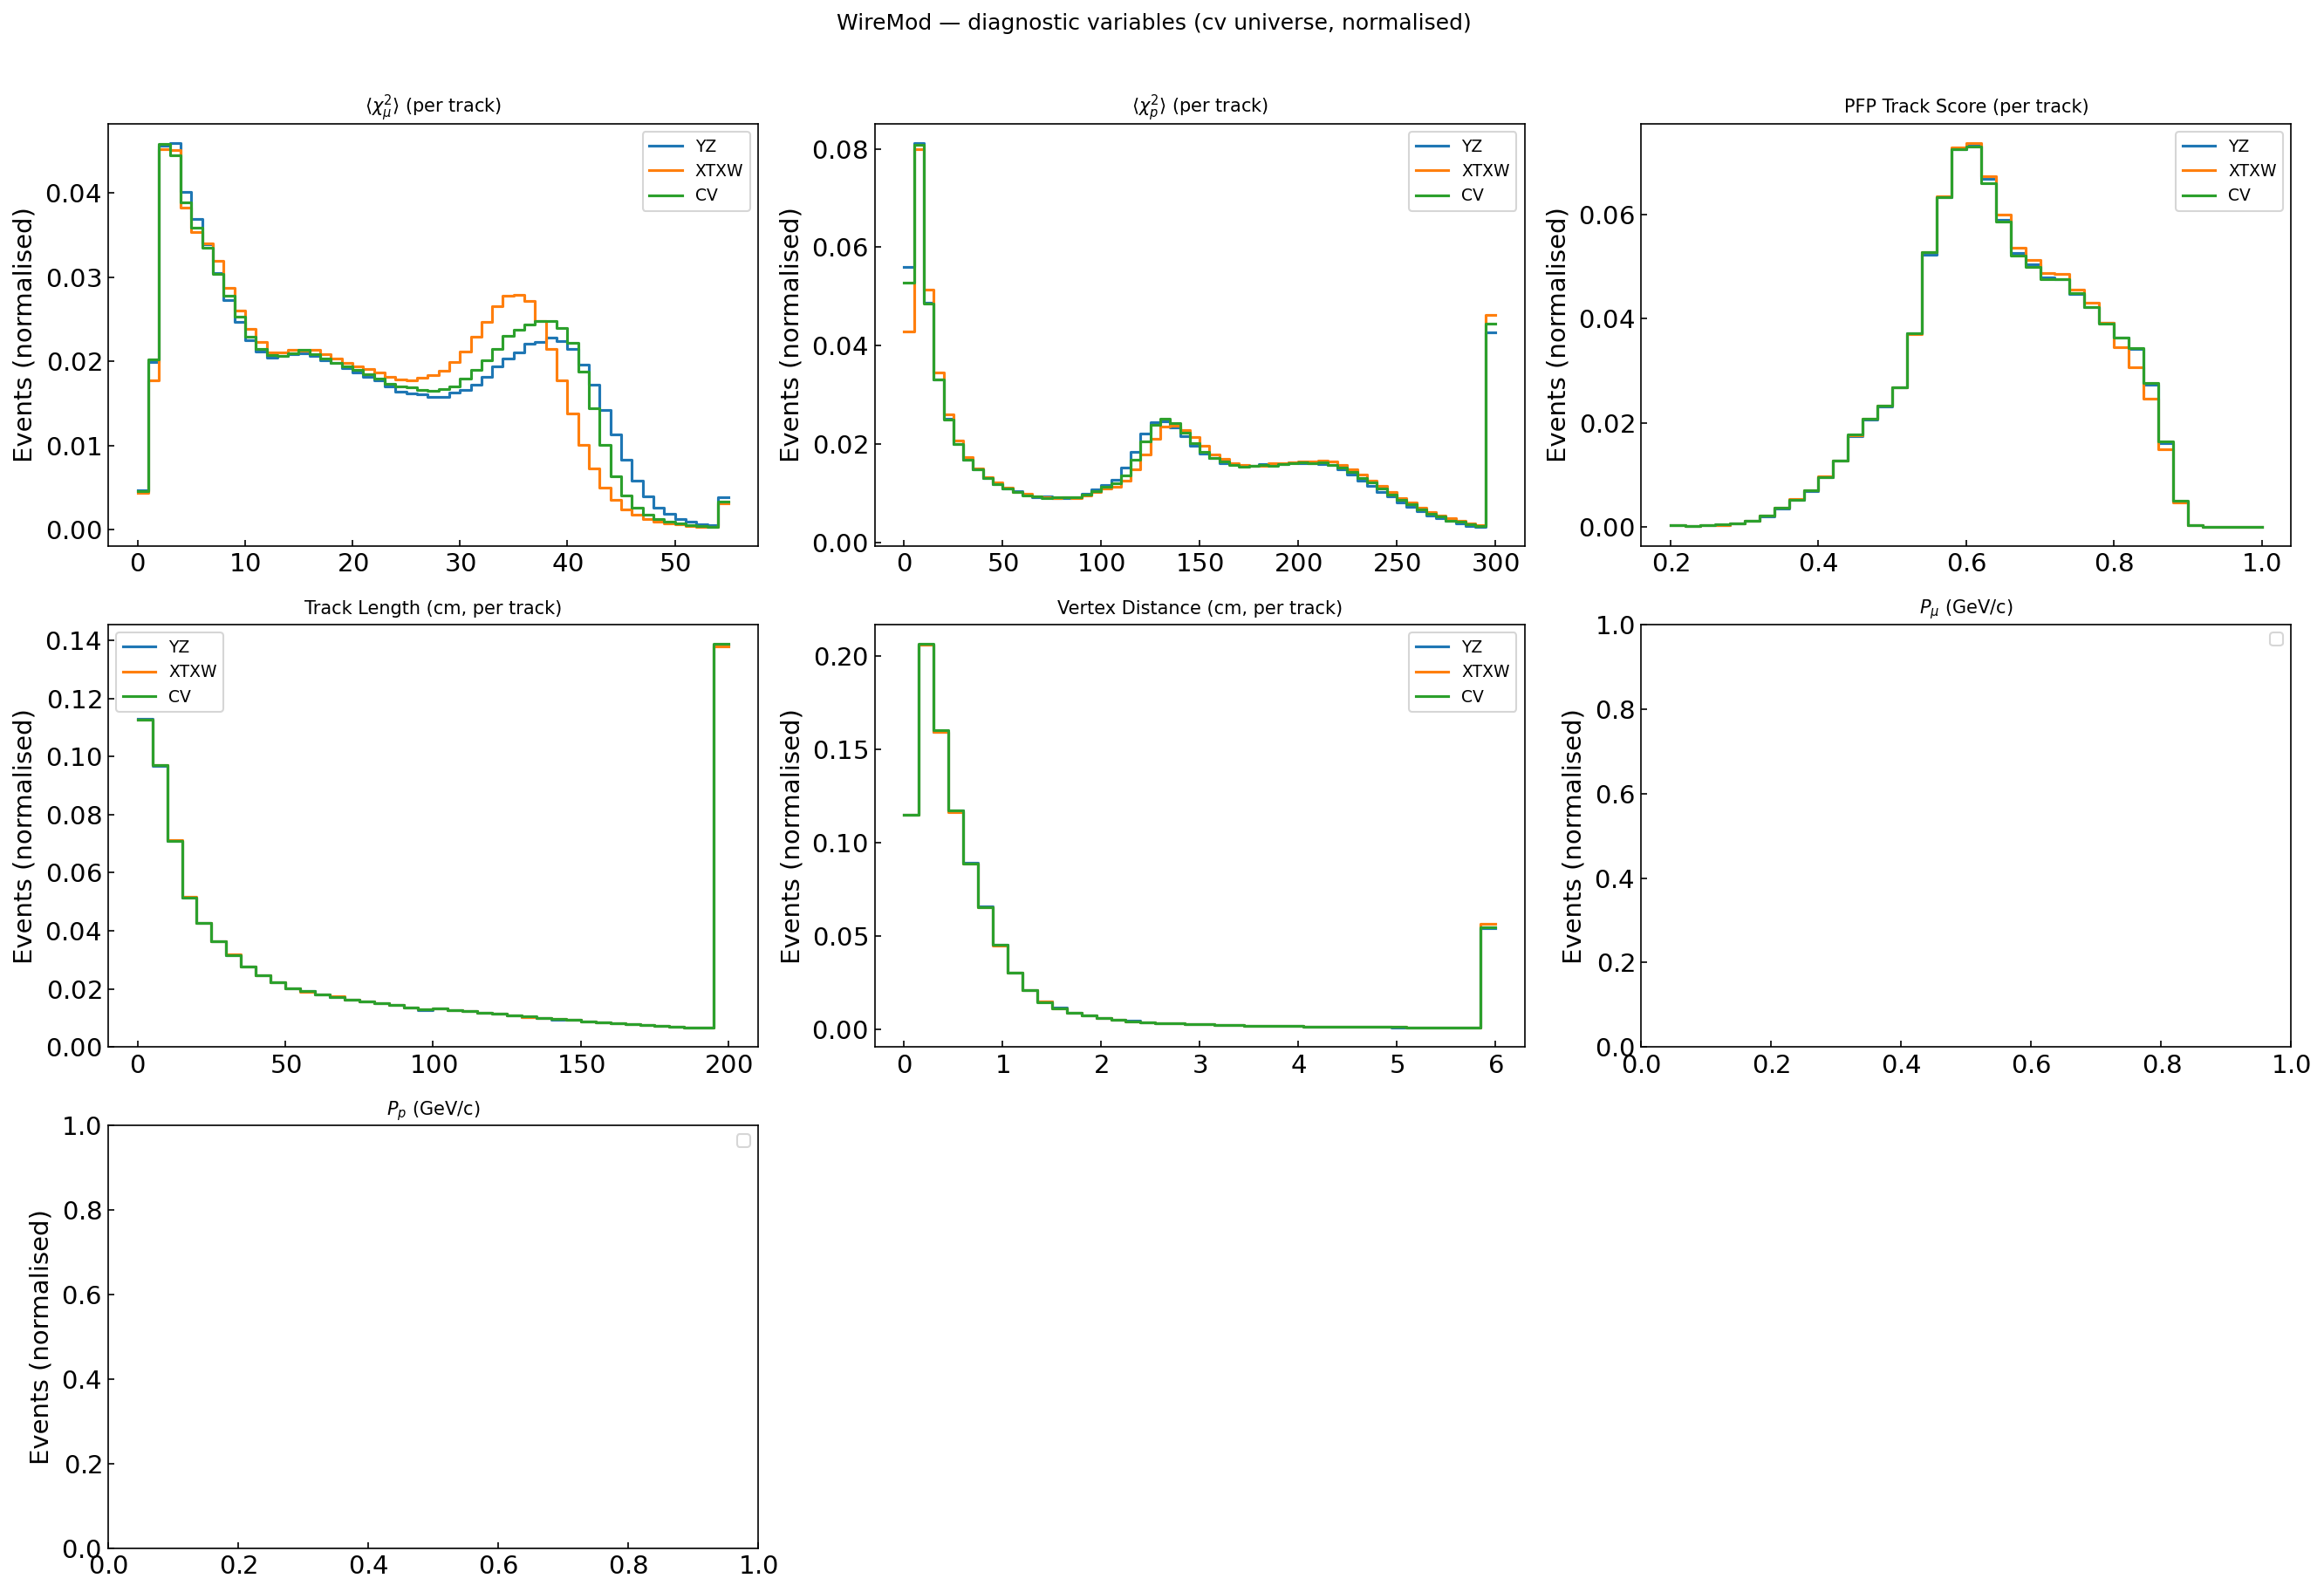

/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots/chi2_comparison.png


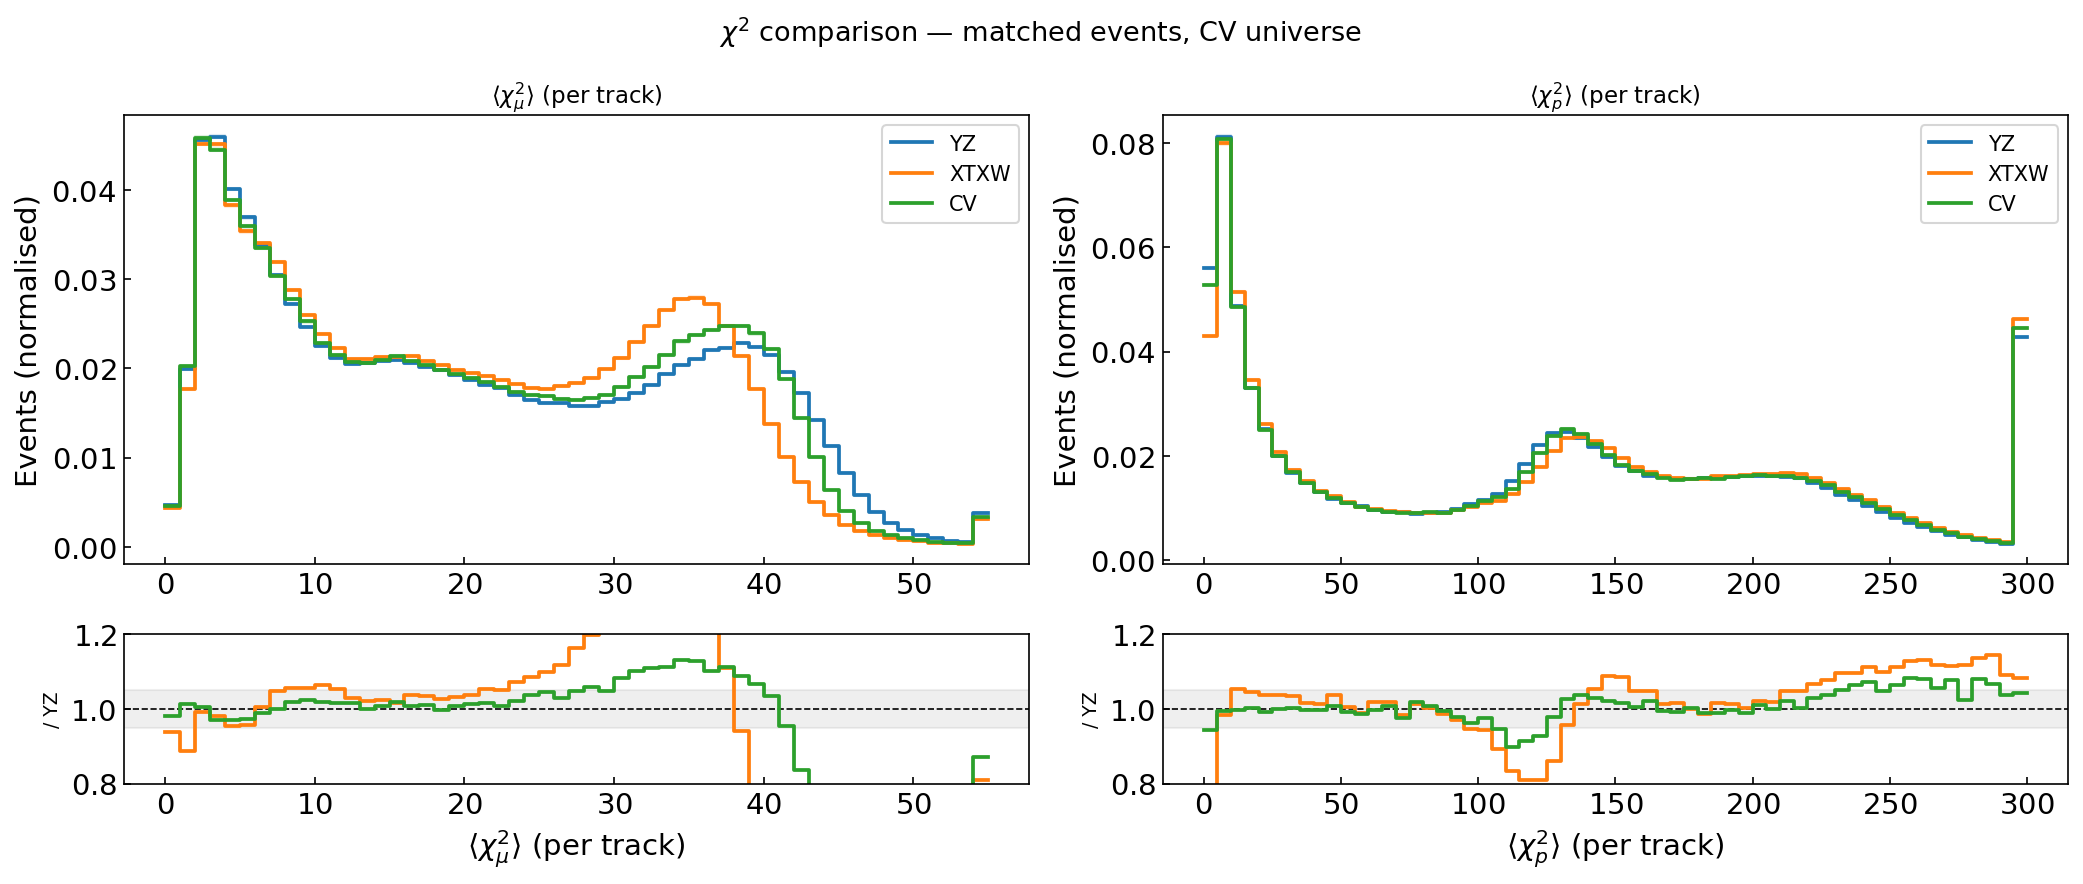

/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots/chi2_calo_envelope.png


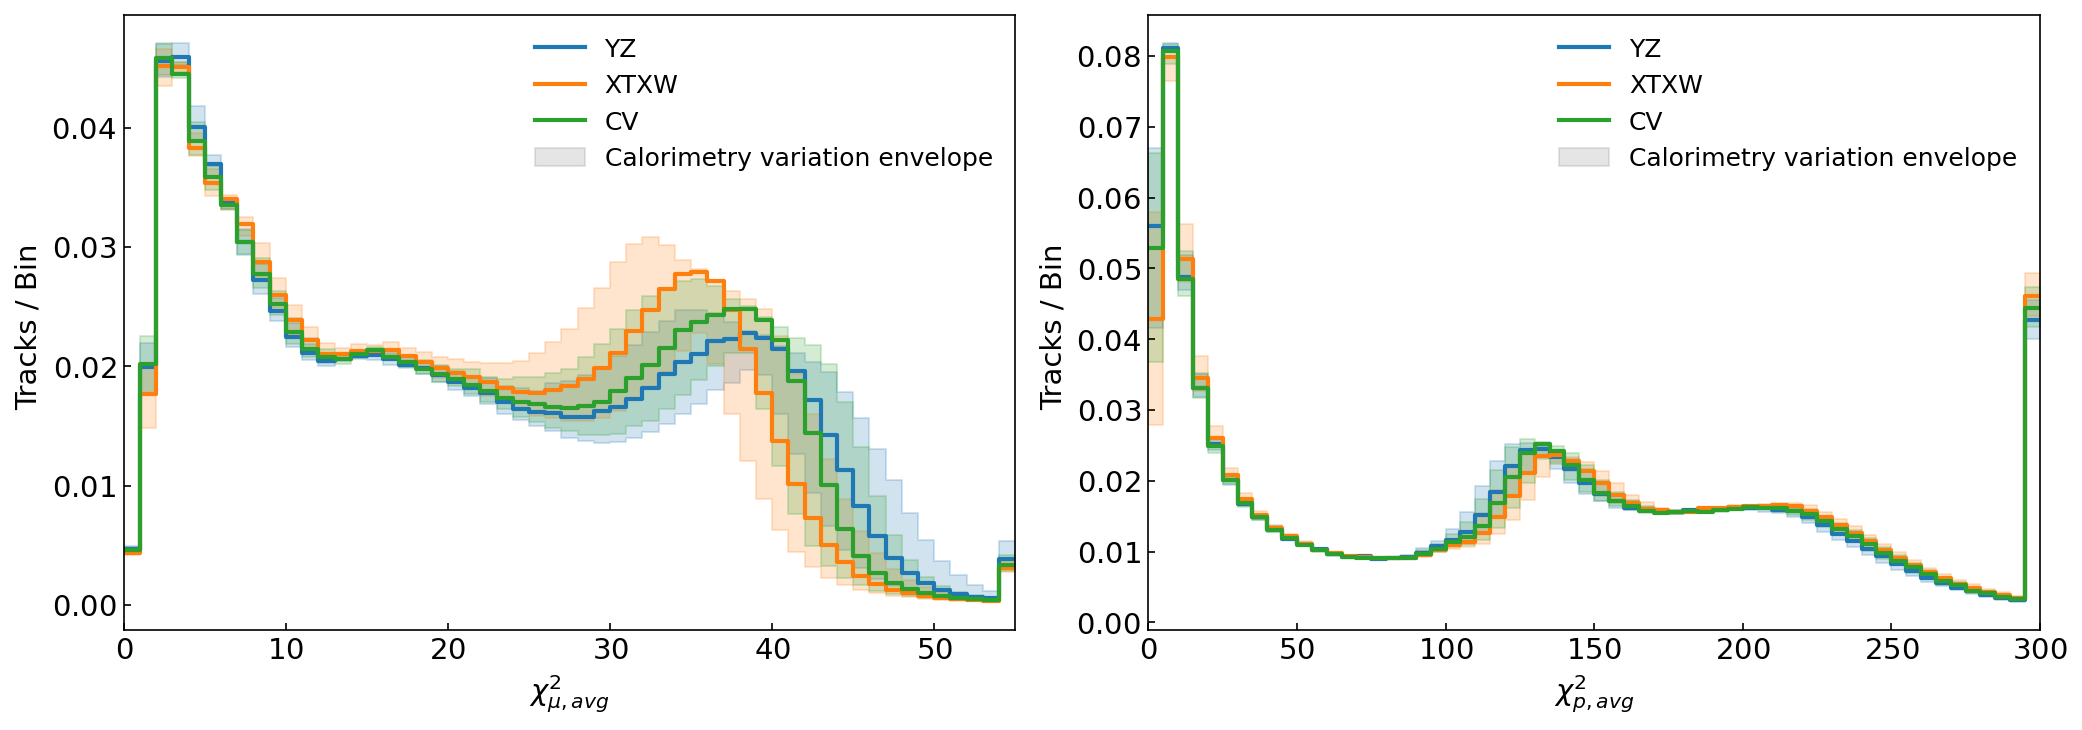

/exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/plots/sel_mup/final_selected_all.png


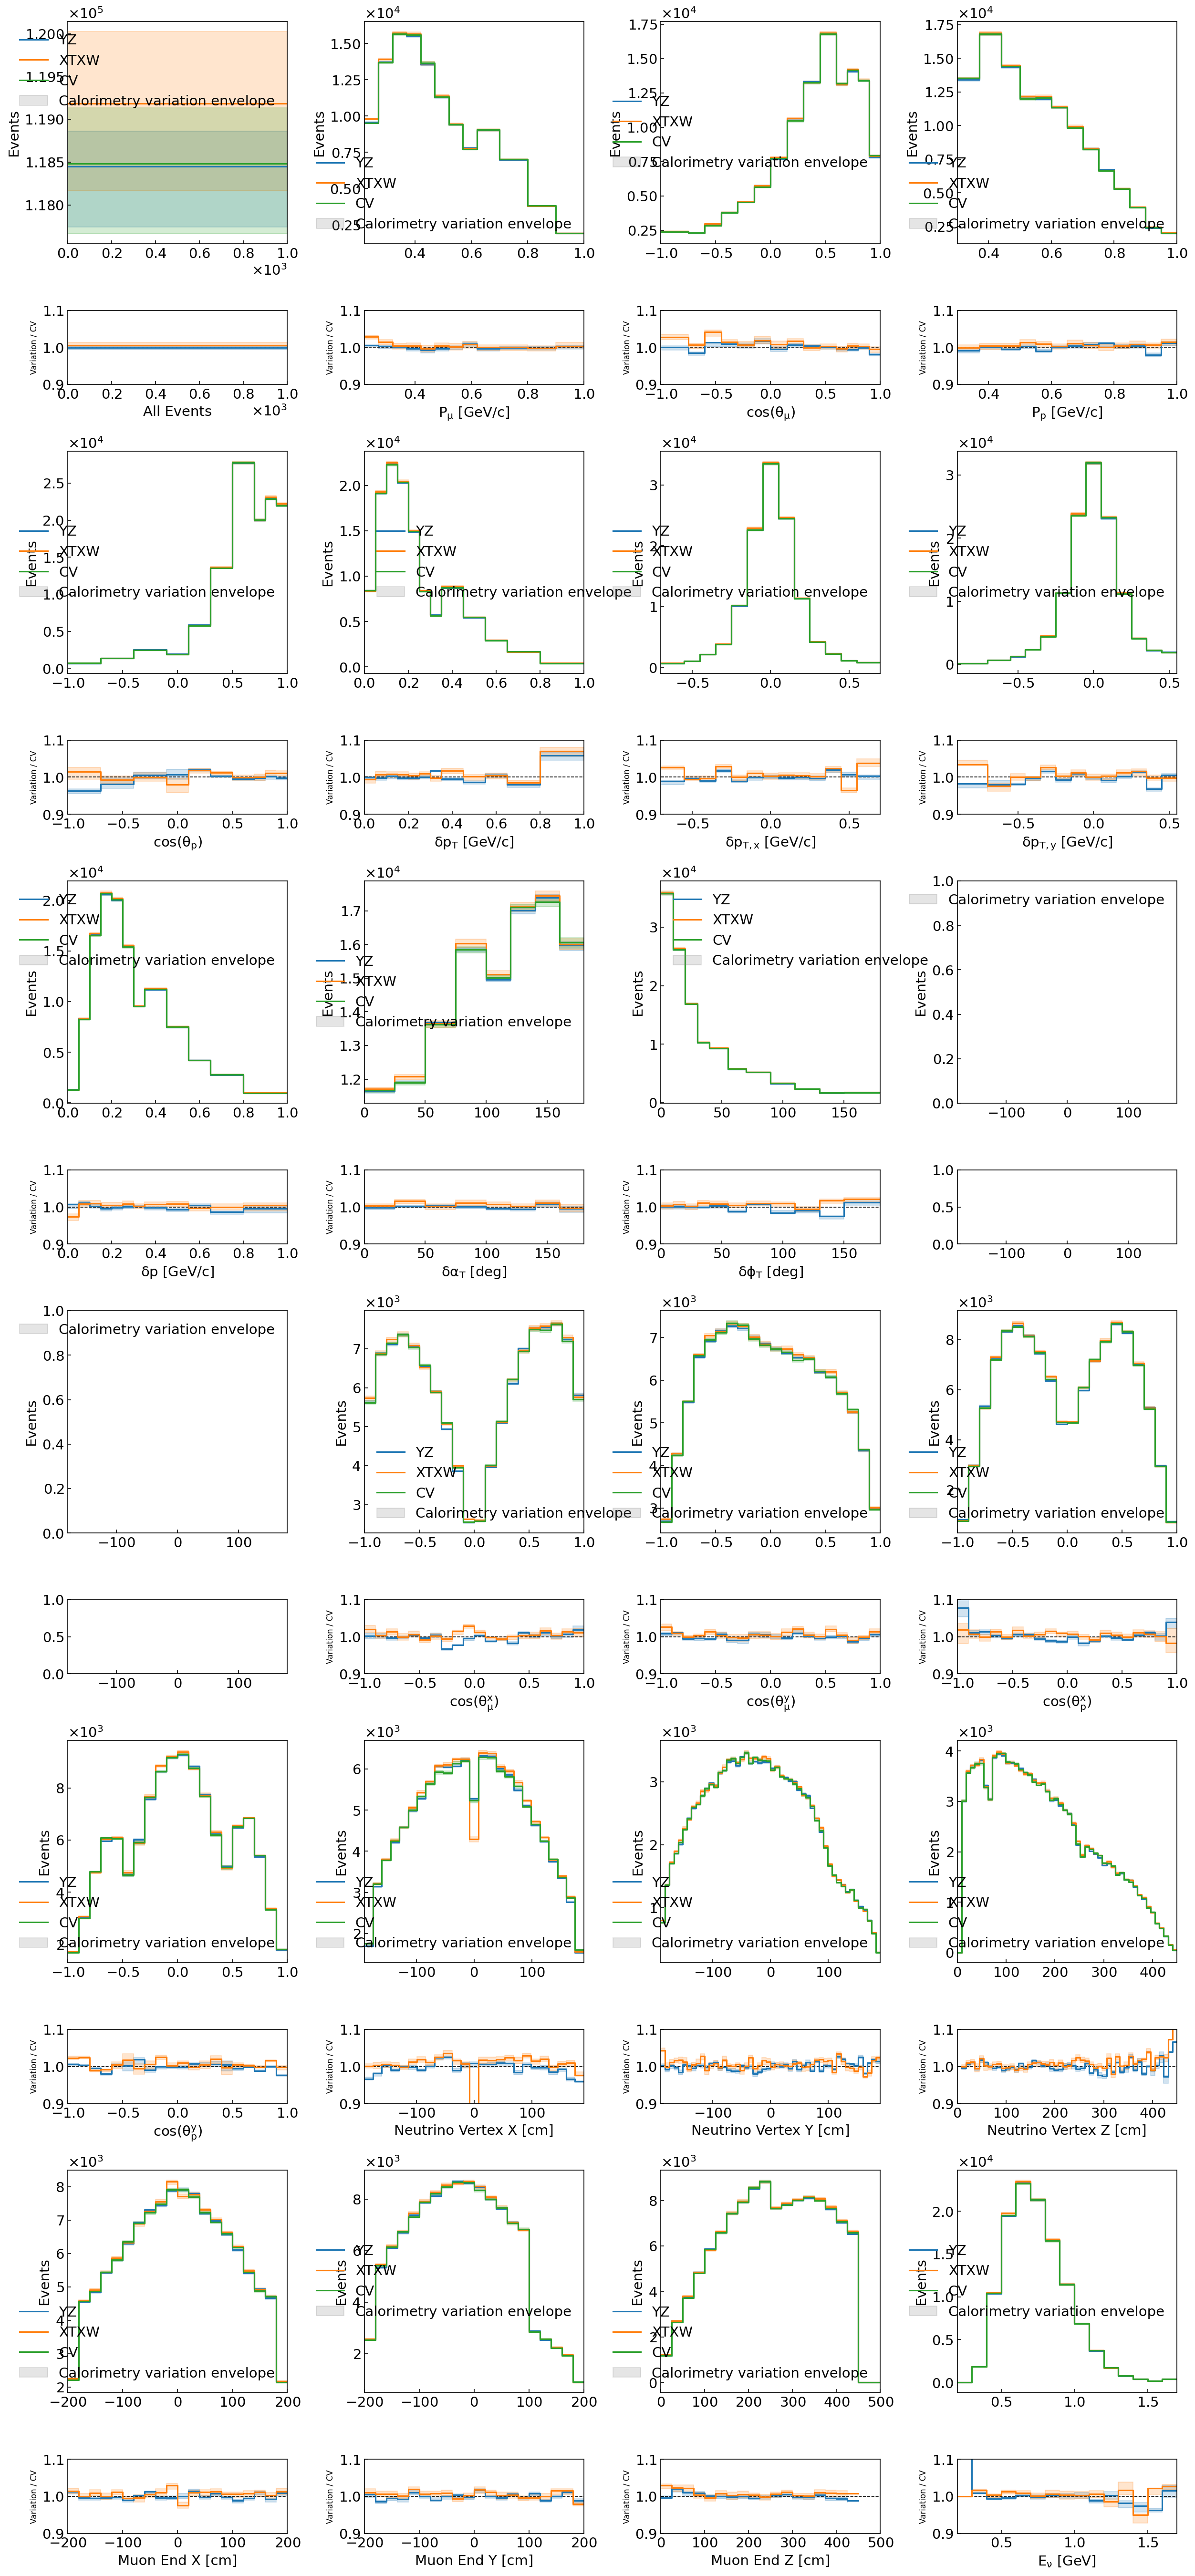

In [16]:
# ── View saved summary figures (no .df loop, no plot rebuild) ─────────────────
from IPython.display import Image, display

for fig_dir, name in [
    (FIG_DIR, "diagnostic_all"),
    (FIG_DIR, "chi2_comparison"),
    (FIG_DIR, "chi2_calo_envelope"),
    (FIG_DIR_MUP, "final_selected_all"),
]:
    fpath = path.join(fig_dir, f"{name}.png")
    if path.isfile(fpath):
        print(fpath)
        display(Image(filename=fpath))
    else:
        print(f"missing: {fpath}")

In [17]:
# Quick sanity check: sel_2prong diagnostic histograms
for vl in all_hists:
    cv_evts = all_nevts[vl]["cv"] if vl in all_nevts else "?"
    nonempty = sum(
        1 for vn in DIAG_VAR_NAMES
        if all_hists[vl]["cv"][vn].sum() > 0
    )
    print(f"{vl}: cv events={cv_evts:,}, diagnostic vars with counts={nonempty}/{len(DIAG_VAR_NAMES)}")

YZ: cv events=1,059,468, diagnostic vars with counts=5/7
XTXW: cv events=1,084,789, diagnostic vars with counts=5/7
CV: cv events=1,063,844, diagnostic vars with counts=5/7


---

## WireMod unisim covariances (`Detector/detector_syst_dict.npz`)

Envelope unisim for **sel_mup** final-selection variables: for each WireMod geometry (YZ, XTXW), build a 2-universe covariance from **CV** and the **max calo-shift envelope** (no full multisim loop). Saved under `WIREMOD_OUT_BASE/Detector/` in the same NPZ layout as `syst_detvar_aggregate.py` (`detector`, `detector-<tag>`, `detector_by_wiremod`) for `systematics-summary.ipynb`.


In [19]:
# ── WireMod unisim covariances (CV vs max calo envelope) ─────────────────────
# Two knobs per WireMod geometry (YZ, XTXW): one 2-universe unisim each from CV and the
# per-bin maximal calo-shift envelope (same envelope as the final-variable plots).
# Output matches ``Detector/detector_syst_dict.npz`` / ``detector_by_wiremod`` layout from
# ``syst_detvar_aggregate.py`` so ``systematics-summary.ipynb`` can plot them like Flux/G4 knobs.

import json
from pyanalib.covariance import cov_from_fraccov, get_covariance_matrix
from analysis_village.numucc_1p0pi.syst_disk_layout import FILE_DETECTOR, SUB_DETECTOR
from analysis_village.numucc_1p0pi.final_selected_evt_vars import (
    CORE_SELECTED_EVT_VARIABLE_CONFIGS,
    with_final_selected_evt_variables,
)
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig

RUN_WIREMOD_COV = True
WIREMOD_COV_VAR_LABELS = ("YZ", "XTXW")  # matched WireMod variations (exclude CV reference)
WIREMOD_KNOB_TAGS = {"YZ": "wiremod_yz", "XTXW": "wiremod_xtxw"}
DETECTOR_SYST_DIR = path.join(WIREMOD_OUT_BASE, SUB_DETECTOR)
DETECTOR_NPZ_PATH = path.join(DETECTOR_SYST_DIR, FILE_DETECTOR)
DETECTOR_MANIFEST_PATH = path.join(WIREMOD_OUT_BASE, "wiremod_detector_covariance_manifest.json")


def _sanitize_matrix_pack(ret):
    return {
        k: np.nan_to_num(np.asarray(ret[k], dtype=float), nan=0.0, posinf=0.0, neginf=0.0)
        for k in ("cov", "cov_frac", "corr")
    }


def _shifted_univ_keys(hists, shifted_univs=None):
    if shifted_univs is not None:
        return [u for u in shifted_univs if u in hists]
    return [u for u in hists if u != "cv"]


def max_envelope_univ_counts(n_cv, hists, var_name, shifted_univs):
    """Per-bin CV + larger-magnitude shift among all calo-shift universes."""
    n_cv = np.asarray(n_cv, dtype=float)
    keys = _shifted_univ_keys(hists, shifted_univs)
    if not keys:
        return n_cv.copy()
    stacked = np.stack(
        [np.asarray(hists[u][var_name], dtype=float) for u in keys],
        axis=0,
    )
    lo = stacked.min(axis=0)
    hi = stacked.max(axis=0)
    diffs_hi = hi - n_cv
    diffs_lo = lo - n_cv
    pick_hi = np.abs(diffs_hi) >= np.abs(diffs_lo)
    chosen = np.where(pick_hi, diffs_hi, diffs_lo)
    return n_cv + chosen * 2


def cov_pack_two_universe(n_cv, n_var):
    ret = get_covariance_matrix(
        np.asarray([n_var], dtype=float),
        np.asarray(n_cv, dtype=float),
    )
    return _sanitize_matrix_pack(ret)


def build_wiremod_var_configs(var_names):
    extra = [
        VariableConfig.vertex_x(),
        VariableConfig.vertex_y(),
        VariableConfig.vertex_z(),
        VariableConfig.muon_direction_x(),
        VariableConfig.muon_direction_y(),
        VariableConfig.proton_direction_x(),
        VariableConfig.proton_direction_y(),
    ]
    configs = with_final_selected_evt_variables(
        list(CORE_SELECTED_EVT_VARIABLE_CONFIGS) + extra
    )
    ne = VariableConfig.neutrino_energy()
    if ne.var_save_name not in {c.var_save_name for c in configs}:
        configs.append(ne)
    by_name = {c.var_save_name: c for c in configs}
    return [by_name[n] for n in var_names if n in by_name]


def build_detector_syst_dict_from_matched_hists(
    all_hists,
    var_names,
    wiremod_labels,
    knob_tags,
    shifted_univs,
):
    detector_dict = {"detector": {}}
    for lab in wiremod_labels:
        detector_dict[f"detector-{knob_tags[lab]}"] = {}

    detector_by_wiremod = {}
    shifted = [u for u in shifted_univs if u != "cv"]

    for var_name in var_names:
        per_tag = {}
        cov_frac_total = None
        n_cv_ref = None

        for lab in wiremod_labels:
            if lab not in all_hists:
                continue
            hists = all_hists[lab]
            if "cv" not in hists or var_name not in hists["cv"]:
                continue
            n_cv = hists["cv"][var_name].astype(float)
            if n_cv.sum() <= 0:
                continue
            n_var = max_envelope_univ_counts(n_cv, hists, var_name, shifted)
            pack = cov_pack_two_universe(n_cv, n_var)
            tag = knob_tags[lab]
            per_tag[tag] = pack
            detector_dict[f"detector-{tag}"][var_name] = pack

            if cov_frac_total is None:
                cov_frac_total = pack["cov_frac"].copy()
                n_cv_ref = n_cv
            else:
                cov_frac_total = cov_frac_total + pack["cov_frac"]

        if not per_tag or cov_frac_total is None:
            continue

        cov_total = cov_from_fraccov(cov_frac_total, n_cv_ref)
        corr_total = np.zeros_like(cov_total)
        for i in range(cov_total.shape[0]):
            for j in range(cov_total.shape[1]):
                di = max(float(cov_total[i, i]), 0.0)
                dj = max(float(cov_total[j, j]), 0.0)
                denom = np.sqrt(di * dj)
                corr_total[i, j] = (cov_total[i, j] / denom) if denom > 1e-12 else 0.0

        detector_dict["detector"][var_name] = {
            "cov": cov_total,
            "cov_frac": cov_frac_total,
            "corr": corr_total,
        }
        detector_by_wiremod[var_name] = per_tag

    if detector_by_wiremod:
        detector_dict["detector_by_wiremod"] = detector_by_wiremod
    return detector_dict


# Includes ``integrated`` (all-events rate) when sel_mup cache was rebuilt after adding it to
# ``FINAL_VAR_DEFS``; set ``RUN_ACCUMULATION_MUP = True`` in the cache cell if needed.

if RUN_WIREMOD_COV:
    if "all_hists_mup" not in globals() or not all_hists_mup:
        _wm_payload = load_wiremod_hists(CACHE_PATH_MUP)
        all_hists_mup = _wm_payload["hists"]

    _shifted = [u for u in ALL_UNIVERSES if u != "cv"]
    _var_configs_cov = build_wiremod_var_configs(list(FINAL_VAR_NAMES_MUP))
    if "integrated" not in {vc.var_save_name for vc in _var_configs_cov}:
        _var_configs_cov.append(VariableConfig.all_events())

    wiremod_detector_dict = build_detector_syst_dict_from_matched_hists(
        all_hists_mup,
        [vc.var_save_name for vc in _var_configs_cov],
        WIREMOD_COV_VAR_LABELS,
        WIREMOD_KNOB_TAGS,
        _shifted,
    )

    makedirs(DETECTOR_SYST_DIR, exist_ok=True)
    np.savez(DETECTOR_NPZ_PATH, **wiremod_detector_dict)

    _saved_vars = sorted(wiremod_detector_dict.get("detector", {}).keys())
    _manifest = {
        "schema": "wiremod_envelope_unisim_v1",
        "description": (
            "Matched sel_mup WireMod unisim: per geometry (wiremod_yz, wiremod_xtxw), "
            "2 universes = CV and per-bin max calo-shift envelope. "
            "Combined detector entry sums per-knob cov_frac (independent)."
        ),
        "npz_path": DETECTOR_NPZ_PATH,
        "cache_path": CACHE_PATH_MUP,
        "knobs": [WIREMOD_KNOB_TAGS[k] for k in WIREMOD_COV_VAR_LABELS],
        "wiremod_var_labels": list(WIREMOD_COV_VAR_LABELS),
        "shifted_universes": _shifted,
        "variables": _saved_vars,
        "read_in_systematics_summary": (
            "Set detector_npz to this file, or copy/link into SYST_DISK_ROOT/Detector/ "
            "as detector_syst_dict.npz; breakdown uses detector_by_wiremod like Flux *_by_knob."
        ),
    }
    with open(DETECTOR_MANIFEST_PATH, "w") as _mf:
        json.dump(_manifest, _mf, indent=2)

    print(f"Wrote {DETECTOR_NPZ_PATH}")
    print(f"  variables: {len(_saved_vars)}")
    print(f"  knobs: {_manifest['knobs']}")
    print(f"  manifest: {DETECTOR_MANIFEST_PATH}")
    for _kn in _manifest["knobs"]:
        _n = len(wiremod_detector_dict.get(f"detector-{_kn}", {}))
        print(f"    detector-{_kn}: {_n} variable(s)")


Wrote /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/Detector/detector_syst_dict.npz
  variables: 22
  knobs: ['wiremod_yz', 'wiremod_xtxw']
  manifest: /exp/sbnd/data/users/munjung/plots/numucc1p0pi/systematics-final/WireMod/wiremod_detector_covariance_manifest.json
    detector-wiremod_yz: 22 variable(s)
    detector-wiremod_xtxw: 22 variable(s)
